**Setting**

In [1]:
pip install -U sentence-transformers umap-learn hdbscan scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 119.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import re
import time
from google import genai
from google.colab import drive, userdata
from pydantic import BaseModel
from tqdm import tqdm
from typing import List, Literal

import hdbscan
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import umap
from sentence_transformers import SentenceTransformer
import torch
from transformers.models import AutoTokenizer, AutoModel

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
WORK_DIR = "/content/drive/MyDrive/Colab Notebooks/final_project_2/Datasets/Glassdoor Job Reviews/"
API_KEY = userdata.get("GEMINI_API_KEY")

In [5]:
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
pretrained_model = "CultureBERT/roberta-large-dominant-culture"

cb_tokenizer = AutoTokenizer.from_pretrained(pretrained_model, cache_dir=WORK_DIR)
cb_model = AutoModel.from_pretrained(pretrained_model, cache_dir=WORK_DIR)

Some weights of RobertaModel were not initialized from the model checkpoint at CultureBERT/roberta-large-dominant-culture and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
print(cb_model)

NameError: name 'cb_model' is not defined

**Load and inspect dataset**

In [6]:
data = pd.read_csv(WORK_DIR + "glassdoor_reviews.csv", encoding="UTF-8")
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 838566 non-null  object 
 1   date_review          838566 non-null  object 
 2   job_title            838566 non-null  object 
 3   current              838566 non-null  object 
 4   location             541223 non-null  object 
 5   overall_rating       838566 non-null  int64  
 6   work_life_balance    688672 non-null  float64
 7   culture_values       647193 non-null  float64
 8   diversity_inclusion  136066 non-null  float64
 9   career_opp           691065 non-null  float64
 10  comp_benefits        688484 non-null  float64
 11  senior_mgmt          682690 non-null  float64
 12  recommend            838566 non-null  object 
 13  ceo_approv           838566 non-null  object 
 14  outlook              838566 non-null  object 
 15  headline         

In [7]:
df = data.copy()

df["job_title"] = df["job_title"].astype(str).str.strip()
df["job_title"] = df["job_title"].replace(r'^\s*$', pd.NA, regex=True)
df = df.replace(r'^\s*$', pd.NA, regex=True)
df = df.dropna(subset=["firm", "date_review", "job_title", "pros", "cons", "overall_rating"])
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 759488 entries, 1 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 759488 non-null  object 
 1   date_review          759488 non-null  object 
 2   job_title            759488 non-null  object 
 3   current              759488 non-null  object 
 4   location             525797 non-null  object 
 5   overall_rating       759488 non-null  int64  
 6   work_life_balance    630773 non-null  float64
 7   culture_values       601967 non-null  float64
 8   diversity_inclusion  136063 non-null  float64
 9   career_opp           632916 non-null  float64
 10  comp_benefits        630689 non-null  float64
 11  senior_mgmt          625671 non-null  float64
 12  recommend            759488 non-null  object 
 13  ceo_approv           759488 non-null  object 
 14  outlook              759488 non-null  object 
 15  headline             7

In [8]:
print(df.columns)

Index(['firm', 'date_review', 'job_title', 'current', 'location',
       'overall_rating', 'work_life_balance', 'culture_values',
       'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt',
       'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons'],
      dtype='object')


In [9]:
print(df["firm"].unique())
print(len(df["firm"].unique()))

['AFH-Wealth-Management' 'AJ-Bell' 'ALDI' 'AQA' 'ASDA' 'ASOS' 'AXA-UK'
 'Abcam' 'Abertawe-Bro-Morgannwg-University-Health-Board' 'Accenture'
 'Accor' 'Achieving-for-Children' 'ActionCOACH' 'Active-Care-Group'
 'Adecco' 'Age-UK-The-National-Charity' 'AlixPartners' 'American-Express'
 'Amey' 'Angard-Staffing' 'Anglian-Water' 'Anglo-American'
 'Animal-and-Plant-Health-Agency' 'Aon' 'Apple' 'Arcadia' 'Arnold-Clark'
 'AstraZeneca' 'Aviva' 'B-and-M-Retail' 'B-and-Q' 'BAT' 'BBC' 'BDO' 'BHS'
 'BIS' 'BNP-Paribas' 'BNY-Mellon' 'BP' 'BPP-Holdings' 'BT'
 'Babcock-International-Group' 'Babylon-Health' 'Bain-and-Company'
 'Balfour-Beatty' 'Bannatyne-Group' 'Barchester-Healthcare' 'Barclays'
 'Barnardo-s' 'Barnet-and-Chase-Farm-Hospitals-NHS-Trust'
 'Barnett-Waddingham' 'Barratt-Developments' 'Barts-Health-NHS-Trust'
 'BayWa-r-e-renewable-energy' 'Bayer' 'Best-Western'
 'Betsi-Cadwaladr-University-Health-Board'
 'Bill-and-Melinda-Gates-Foundation' 'Birkbeck-College'
 'Birmingham-City-University' 'Blo

In [10]:
df["date_review"] = pd.to_datetime(df["date_review"], format='%Y-%m-%d')

print('Min: ', df["date_review"].min())
print('Max: ', df["date_review"].max())

Min:  2008-01-31 00:00:00
Max:  2021-06-08 00:00:00


In [11]:
print(df["job_title"].unique())

['Office Administrator' 'IFA' 'Anonymous Employee' ...
 'Seasonal Ride Operator/Attendant' 'Service Employee'
 'Senior Experience Designer']


In [12]:
print(df["current"].unique())

['Current Employee, more than 1 year' 'Current Employee, less than 1 year'
 'Former Employee' 'Current Employee, more than 5 years'
 'Former Employee, more than 1 year' 'Former Employee, more than 3 years'
 'Former Employee, more than 5 years'
 'Current Employee, more than 3 years' 'Current Employee'
 'Current Employee, more than 8 years' 'Former Employee, less than 1 year'
 'Former Employee, more than 8 years'
 'Current Employee, more than 10 years'
 'Former Employee, more than 10 years'
 'Former Contractor, less than 1 year' 'Former Intern, less than 1 year'
 'Current Contractor, less than 1 year' 'Former Contractor'
 'Former Intern, more than 1 year' 'Current Contractor' 'Former Intern'
 'Current Intern, less than 1 year' 'Current Contractor, more than 1 year'
 'Former Contractor, more than 1 year'
 'Former Contractor, more than 8 years' 'Former Temporary Employee'
 'KEY NOT FOUND: jobLine.per_diem-former'
 'Current Freelancer, more than 3 years'
 'KEY NOT FOUND: jobLine.temporary-f

In [13]:
print(len(df["location"].unique()))

14315


In [14]:
print(df["recommend"].unique())

['x' 'o' 'v']


In [15]:
print(df["ceo_approv"].unique())

['o' 'r' 'x' 'v']


In [16]:
print(df["outlook"].unique())

['r' 'x' 'v' 'o']


In [17]:
print(df["headline"].str.len().describe())
print(df["headline"][:10])

count    757039.000000
mean         23.415535
std          18.213549
min           1.000000
25%          12.000000
50%          19.000000
75%          29.000000
max         519.000000
Name: headline, dtype: float64
1        Excellent staff, poor salary
2     Low salary, bad micromanagement
4              client reporting admin
5                Office administrator
6              It horrible management
7                  Good place to work
8             I liked working for AFH
9                       Honest Review
10                  Avoid at all cost
11     Worst place I have ever worked
Name: headline, dtype: object


In [18]:
print(df["pros"].str.len().describe())
print(df["pros"][:10])

count    759488.000000
mean         92.280394
std         116.493417
min           7.000000
25%          39.000000
50%          56.000000
75%         104.000000
max       18193.000000
Name: pros, dtype: float64
1         Friendly, helpful and hard-working colleagues
2     Easy to get the job even without experience in...
4                 Easy to get the job, Nice colleagues.
5     Some good people to work with.\n\nFlexible wor...
6     Good investment management strategy. Overall t...
7     The people are great and the culture is very f...
8     Nice Staff, good HR Team.\r\nFeels vibrant and...
9                          Made some life time friends.
10    I can't think of any obvious ones, although I'...
11    Can do compressed hours if you qualify for the...
Name: pros, dtype: object


In [19]:
print(df["cons"].str.len().describe())
print(df["cons"][:10])

count    759488.000000
mean        124.053835
std         232.204339
min           1.000000
25%          37.000000
50%          57.000000
75%         122.000000
max       10777.000000
Name: cons, dtype: float64
1     Poor salary which doesn't improve much with pr...
2     Very low salary, poor working conditions, very...
4     Abysmal pay, around minimum wage. No actual tr...
5     Morale.\n\nLack of managerial structure.\n\nDo...
6     The management and seniors are ruthless. No tr...
7     Wouldn't necessarily say there are any cons to...
8                Can't really think of any obvious cons
9     Was let go from the company just before Christ...
10    Disgustingly low wages. Staff are not valued. ...
11    Unsupportive HR team, worst I have ever come a...
Name: cons, dtype: object


**Industry Classification**

In [23]:
client = genai.Client(api_key=API_KEY)
industry_options = [
    "Technology / Software", "Telecommunications", "Financial Services",
    "Banking", "Insurance", "Consulting / Professional Services",
    "Accounting / Audit", "Legal Services", "Healthcare / Medical Services",
    "Biotechnology / Pharmaceuticals", "Education / Academic Institutions", "Research Institutes",
    "Manufacturing", "Automotive", "Aerospace / Defense", "Energy / Utilities",
    "Mining / Resources", "Retail / Wholesale", "E-commerce",
    "Logistics / Transportation", "Real Estate / Property Management", "Hospitality / Tourism",
    "Entertainment / Media", "Sports Organizations", "Agriculture / Food Production",
    "Public Sector / Government Agencies", "Municipal Services", "Nonprofit Organizations (NPO/NGO)",
    "International Organizations (UN, WHO, etc.)", "Religious Organizations", "Foundations / Charitable Organizations",
    "Labor Unions / Worker Associations", "Political Organizations / Parties", "Environmental Organizations",
    "Human Rights Organizations", "Social Services / Community Organizations", "Startups / Early-Stage Ventures",
    "Investment Firms / Private Equity / Venture Capital"
]

class IndustrySpecification(BaseModel):
    industry: str

def classify_company(company_name: str, retries: int=3, industry_options: List=industry_options):
    """Classify companies into certain numbers of industries based on GICS: https://www.msci.com/indexes/index-resources/gics"""
    for attempt in range(retries):

        prompt = f"""
        Classify the following UK-based company into one primary industry category:
        {company_name}

        Choose one from:
        {industry_options}
        """

        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
            config={
            "response_mime_type": "application/json",
            "response_json_schema": IndustrySpecification.model_json_schema()
            }
        )

        industry = IndustrySpecification.model_validate_json(response.text).industry

        if industry in industry_options:
            return industry

        print(f"Retrying... invalid output '{industry}' (attempt {attempt+1})")

    raise ValueError(f"Could not classify '{company_name}' after {retries} attempts.")

In [24]:
for c in df["firm"].unique()[:10]:
    print(c)
    print(classify_company(c))

AFH-Wealth-Management
Financial Services
AJ-Bell
Financial Services
ALDI
Retail / Wholesale
AQA
Education / Academic Institutions
ASDA
Retail / Wholesale
ASOS
E-commerce
AXA-UK
Insurance
Abcam
Biotechnology / Pharmaceuticals
Abertawe-Bro-Morgannwg-University-Health-Board
Healthcare / Medical Services
Accenture
Consulting / Professional Services


In [25]:
company_list = df["firm"].unique()
company_map = {}

for company in company_list:
    category = classify_company(company)
    company_map[company] = category

In [26]:
df_map = pd.DataFrame.from_dict(company_map, orient="index", columns=["industry"])
df_map.index.name = "company"
df_map.reset_index(inplace=True)
df_map.to_csv("company_industry_map.csv", index=False)

In [27]:
# company_industry_mapの取り込み
company_industry_map = pd.read_csv(WORK_DIR + "company_industry_map.csv", encoding="UTF-8")
print(company_industry_map.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   company   428 non-null    object
 1   industry  428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


In [27]:
df2 = df.merge(company_industry_map, left_on="firm", right_on="company", how="left")

In [28]:
print(df2[["overall_rating", "culture_values"]].describe())

       overall_rating  culture_values
count   759488.000000   601967.000000
mean         3.666654        3.597446
std          1.177950        1.324899
min          1.000000        1.000000
25%          3.000000        3.000000
50%          4.000000        4.000000
75%          5.000000        5.000000
max          5.000000        5.000000


In [29]:
print(df2["overall_rating"].value_counts())

overall_rating
4    251327
5    214616
3    172973
2     66901
1     53671
Name: count, dtype: int64


In [41]:
words = ["design thinking", "human centered approach"]
pattern = "|".join(words)

count = df["pros"].str.contains(pattern, case=False, na=False).sum()
print(count)
count2 = df["cons"].str.contains(pattern, case=False, na=False).sum()
print(count2)

52
14


In [65]:
df_IT = df2[df2["industry"] == "Information Technology"].copy()
print(df_IT.info())

<class 'pandas.core.frame.DataFrame'>
Index: 168579 entries, 6926 to 755401
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   firm                 168579 non-null  object        
 1   date_review          168579 non-null  datetime64[ns]
 2   job_title            168579 non-null  object        
 3   current              168579 non-null  object        
 4   location             118067 non-null  object        
 5   overall_rating       168579 non-null  int64         
 6   work_life_balance    146856 non-null  float64       
 7   culture_values       136739 non-null  float64       
 8   diversity_inclusion  25346 non-null   float64       
 9   career_opp           147008 non-null  float64       
 10  comp_benefits        146945 non-null  float64       
 11  senior_mgmt          145890 non-null  float64       
 12  recommend            168579 non-null  object        
 13  ceo_approv      

In [28]:
firms = [
    "Accenture", "ActionCOACH", "Adecco",
    "AlixPartners", "Angard-Staffing", "Apple",
    "Bain-and-Company", "Barnett-Waddingham", "Blue-Arrow",
    "Blue-Yonder", "Boston-Consulting-Group", "Brook-Street",
    "Bullhorn", "Capita", "Cisco-Systems", "Cougar-Mountain",
    "Creative-Support", "Deloitte", "Dynatrace",
    "EY", "Egon-Zehnder", "FYXER",
    "Facebook", "Gi-Group", "Google",
    "Grant-Thornton-UK-LLP", "Hays", "IBM",
    "Indeed", "Intelligent-Office-UK", "Iron-Mountain-Inc",
    "KPMG", "Korn-Ferry", "LinkedIn",
    "Manpower", "McKinsey-and-Company", "Mercer",
    "Microsoft", "Mitie", "Odgers-Berndtson",
    "Office-Angels", "Office-Concierge", "Oliver-Wyman",
    "Oracle", "People-Group", "Pertemps",
    "PwC", "REED", "Randstad",
    "Rentokil-Initial", "Robert-Walters", "Ryan-LLC",
    "SAP", "Sage", "Salesforce",
    "Search-Consultancy", "Tate-Recruitment", "The-Access-Group-UK",
    "Time-Etc", "Unity-Technologies", "VMware",
    "WLT-Group", "Wipro", "Workday"
]

In [31]:
target_df = df[df["firm"].isin(firms)].copy()
print(target_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 335321 entries, 7297 to 833084
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   firm                 335321 non-null  object        
 1   date_review          335321 non-null  datetime64[ns]
 2   job_title            335321 non-null  object        
 3   current              335321 non-null  object        
 4   location             233784 non-null  object        
 5   overall_rating       335321 non-null  int64         
 6   work_life_balance    282505 non-null  float64       
 7   culture_values       265557 non-null  float64       
 8   diversity_inclusion  58420 non-null   float64       
 9   career_opp           283292 non-null  float64       
 10  comp_benefits        282753 non-null  float64       
 11  senior_mgmt          280602 non-null  float64       
 12  recommend            335321 non-null  object        
 13  ceo_approv      

In [32]:
target_df["firm"].unique()

array(['Accenture', 'ActionCOACH', 'Adecco', 'AlixPartners',
       'Angard-Staffing', 'Apple', 'Bain-and-Company',
       'Barnett-Waddingham', 'Blue-Arrow', 'Blue-Yonder',
       'Boston-Consulting-Group', 'Brook-Street', 'Bullhorn', 'Capita',
       'Cisco-Systems', 'Cougar-Mountain', 'Creative-Support', 'Deloitte',
       'Dynatrace', 'EY', 'Egon-Zehnder', 'FYXER', 'Facebook', 'Gi-Group',
       'Google', 'Grant-Thornton-UK-LLP', 'Hays', 'IBM', 'Indeed',
       'Intelligent-Office-UK', 'Iron-Mountain-Inc', 'KPMG', 'Korn-Ferry',
       'LinkedIn', 'Manpower', 'McKinsey-and-Company', 'Mercer',
       'Microsoft', 'Mitie', 'Odgers-Berndtson', 'Office-Angels',
       'Office-Concierge', 'Oliver-Wyman', 'Oracle', 'People-Group',
       'Pertemps', 'PwC', 'REED', 'Randstad', 'Rentokil-Initial',
       'Robert-Walters', 'Ryan-LLC', 'SAP', 'Sage', 'Salesforce',
       'Search-Consultancy', 'Tate-Recruitment', 'The-Access-Group-UK',
       'Time-Etc', 'Unity-Technologies', 'VMware', 'WLT-Gr

In [66]:
print(df_IT["firm"].unique())

['Accenture' 'Apple' 'Blue-Yonder' 'Bullhorn' 'Cisco-Systems'
 'Cougar-Mountain' 'Dynatrace' 'IBM' 'Indeed' 'Iron-Mountain-Inc'
 'Microsoft' 'Oracle' 'Ordnance-Survey' 'Ryan-LLC' 'SAP' 'Sage'
 'Salesforce' 'The-Access-Group-UK' 'Thomson-Reuters' 'Unity-Technologies'
 'VMware' 'Wipro' 'Workday' 'i-Net-Solution']


In [33]:
target_df["year"] = pd.to_datetime(target_df["date_review"]).dt.year

In [34]:
year_counts = target_df.groupby(["firm", "year"]).size().reset_index(name="count")
print(year_counts)

          firm  year  count
0    Accenture  2008     32
1    Accenture  2009     33
2    Accenture  2010     38
3    Accenture  2011     18
4    Accenture  2012     59
..         ...   ...    ...
730    Workday  2017    196
731    Workday  2018    204
732    Workday  2019    214
733    Workday  2020    225
734    Workday  2021    310

[735 rows x 3 columns]


In [35]:
pivot = year_counts.pivot(index="firm", columns="year", values="count").fillna(0)
print(pivot)

year                2008  2009  2010  2011  2012  2013   2014   2015   2016  \
firm                                                                          
Accenture           32.0  33.0  38.0  18.0  59.0  81.0   82.0  158.0  192.0   
ActionCOACH          0.0   0.0   0.0   0.0   1.0   4.0    7.0    3.0    1.0   
Adecco              11.0  10.0  17.0  25.0  66.0  67.0  117.0  266.0  341.0   
AlixPartners         0.0   0.0   1.0   0.0   0.0   0.0    1.0    6.0    3.0   
Angard-Staffing      0.0   0.0   0.0   0.0   0.0   0.0    0.0    0.0   17.0   
...                  ...   ...   ...   ...   ...   ...    ...    ...    ...   
Unity-Technologies   0.0   0.0   0.0   0.0   1.0   2.0    3.0   12.0   20.0   
VMware               2.0   0.0   0.0   0.0   1.0   2.0    5.0   12.0   22.0   
WLT-Group            6.0   4.0   6.0   7.0  34.0  35.0   91.0  104.0  132.0   
Wipro                2.0   1.0   3.0   8.0  19.0  19.0   12.0   27.0   19.0   
Workday              0.0   0.0   3.0   4.0  23.0  25

In [47]:
filtered = pivot[(pivot[2015] > 0) & (pivot[2021] > 0)]
print(filtered.index)

Index(['Accenture', 'ActionCOACH', 'Adecco', 'AlixPartners', 'Apple',
       'Bain-and-Company', 'Barnett-Waddingham', 'Blue-Arrow', 'Blue-Yonder',
       'Boston-Consulting-Group', 'Brook-Street', 'Bullhorn', 'Capita',
       'Cisco-Systems', 'Cougar-Mountain', 'Creative-Support', 'Deloitte',
       'Dynatrace', 'EY', 'Egon-Zehnder', 'Facebook', 'Gi-Group', 'Google',
       'Grant-Thornton-UK-LLP', 'Hays', 'IBM', 'Indeed', 'Iron-Mountain-Inc',
       'KPMG', 'Korn-Ferry', 'LinkedIn', 'Manpower', 'McKinsey-and-Company',
       'Mercer', 'Microsoft', 'Mitie', 'Odgers-Berndtson', 'Office-Angels',
       'Office-Concierge', 'Oliver-Wyman', 'Oracle', 'People-Group',
       'Pertemps', 'PwC', 'REED', 'Randstad', 'Rentokil-Initial',
       'Robert-Walters', 'Ryan-LLC', 'SAP', 'Sage', 'Salesforce',
       'Search-Consultancy', 'Tate-Recruitment', 'The-Access-Group-UK',
       'Unity-Technologies', 'VMware', 'WLT-Group', 'Wipro', 'Workday'],
      dtype='object', name='firm')


In [67]:
print('Min: ', df_IT["date_review"].min())
print('Max: ', df_IT["date_review"].max())

Min:  2008-01-31 00:00:00
Max:  2021-06-06 00:00:00


In [68]:
df_IT["year"] = pd.to_datetime(df["date_review"]).dt.year

In [70]:
year_counts = df_IT.groupby(["firm", "year"]).size().reset_index(name="count")
print(year_counts)

               firm    year  count
0         Accenture  2008.0     32
1         Accenture  2009.0     33
2         Accenture  2010.0     38
3         Accenture  2011.0     18
4         Accenture  2012.0     59
..              ...     ...    ...
154         Workday  2018.0    253
155         Workday  2019.0    266
156         Workday  2020.0    270
157         Workday  2021.0    339
158  i-Net-Solution  2015.0      2

[159 rows x 3 columns]


In [72]:
pivot = year_counts.pivot(index="firm", columns="year", values="count").fillna(0)
print(pivot)

year                 2008.0  2009.0  2010.0  2011.0  2012.0  2013.0  2014.0  \
firm                                                                          
Accenture              32.0    33.0    38.0    18.0    59.0    82.0    88.0   
Apple                 309.0   164.0   160.0   235.0   416.0   740.0  1199.0   
Blue-Yonder             4.0    13.0    16.0    13.0    63.0    75.0   133.0   
Bullhorn                0.0     0.0     0.0     0.0     0.0     0.0     0.0   
Cisco-Systems          27.0    17.0    21.0    31.0    19.0     0.0     0.0   
Cougar-Mountain         0.0     0.0     0.0     0.0     0.0     0.0     0.0   
Dynatrace               0.0     0.0     0.0     0.0     0.0     0.0     0.0   
IBM                   838.0   739.0  1046.0  1143.0  2740.0  2869.0  3961.0   
Indeed                  0.0     0.0     0.0     0.0     0.0     0.0     0.0   
Iron-Mountain-Inc       0.0     0.0     0.0     0.0     0.0     0.0     0.0   
Microsoft               0.0     0.0     0.0     0.0 

In [123]:
print(df_IT["job_title"].unique()[:10])
print(len(df_IT["job_title"].unique()))

['Outsourcing Sales Executive' 'Consultant'
 'Management Consulting Senior Consultant' 'Software Engineer'
 'Systems Integration Consultant' 'Analyst' 'Senior Manager'
 'Management Consulting Senior Manager' 'Senior Consultant' 'Manager']
5220


In [124]:
exclusion_keywords = [
    'intern', 'internship', 'apprentice', 'trainee',
    'part time', 'part-time', 'student',
    'driver', 'cleaner', 'warehouse', 'security',
    'freelance', 'contractor'
]

df_IT_cleaned = df_IT[~df_IT['job_title'].str.lower().str.contains('|'.join(exclusion_keywords), na=False)]

print(f"フィルタリング前: {len(df_IT)}")
print(f"フィルタリング後: {len(df_IT_cleaned)}")

フィルタリング前: 37695
フィルタリング後: 37321


**PROS**

preprocesing

In [125]:
df_IT_cleaned = df_IT_cleaned.copy()

In [126]:
companies = df_IT_cleaned["firm"].unique()
pattern = r'\b(' + '|'.join(companies) + r')\b'

df_IT_cleaned['clean_pros'] = df_IT_cleaned['pros'].str.replace(pattern, '', regex=True, flags=re.IGNORECASE)

In [127]:
pros_list = df_IT_cleaned["clean_pros"].tolist()

In [128]:
print(df_IT_cleaned["clean_pros"].str.len().describe())

count    37321.000000
mean        98.313068
std        108.799187
min         12.000000
25%         41.000000
50%         62.000000
75%        118.000000
max       2878.000000
Name: clean_pros, dtype: float64


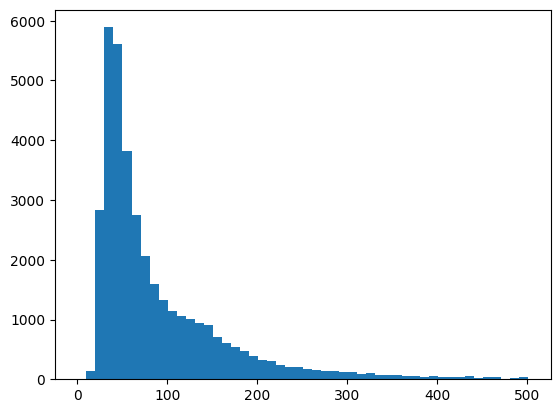

In [129]:
plt.hist(df_IT_cleaned["clean_pros"].str.len(), bins=50, range=[0, 501])
plt.show()

sentence_transformers

In [38]:
pros_embeddings = st_model.encode(pros_list, batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/584 [00:00<?, ?it/s]

In [39]:
pca = PCA(n_components=50)
pca_pros_embeddings = pca.fit_transform(pros_embeddings)

In [40]:
reducer = umap.UMAP(
    n_neighbors=100,
    metric="cosine"
)

umap_pros_embeddings = reducer.fit_transform(pca_pros_embeddings)

In [42]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
)

pros_labels = clusterer.fit_predict(umap_pros_embeddings)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


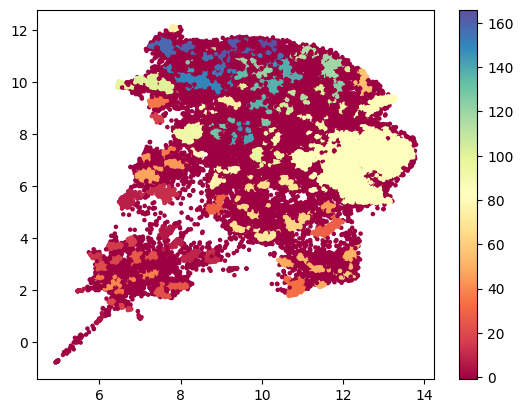

In [43]:
plt.scatter(umap_pros_embeddings[:,0], umap_pros_embeddings[:,1], c=pros_labels, cmap='Spectral', s=5)
plt.colorbar()
plt.show()

In [44]:
df_IT_cleaned['cluster'] = pros_labels
print(df_IT_cleaned['cluster'].value_counts())

cluster
-1      15990
 84      5942
 150      812
 92       593
 119      529
        ...  
 67        15
 113       15
 54        15
 27        15
 32        15
Name: count, Length: 168, dtype: int64


In [45]:
def get_representative_samples(df, column, cluster, n=10):
    return df[df[column]==cluster].sample(n)['clean_pros'].tolist()

In [93]:
class ClusterLabeling(BaseModel):
    topic: str

def analyze_cluster(df, column, cluster, embeddings, referred_column, n=5):
    """"""
    mask = df[column] == cluster
    cluster_df = df.loc[mask].copy().reset_index(drop=True)

    if len(cluster_df) == 0:
        return ["Empty cluster"]

    cluster_embeddings = embeddings[mask.values]

    centroid = cluster_embeddings.mean(axis=0)
    sims = cosine_similarity([centroid], cluster_embeddings)[0]

    n_use = min(n, len(cluster_df))
    top_idx = np.argsort(sims)[::-1][:n_use]

    top_sentences = cluster_df.iloc[top_idx][referred_column].tolist()

    prompt = f"""
    Analyze the following top {n} representative sentences from one cluster.
    Identify the central theme, key idea, and the shared meaning expressed across the sentences.
    Write the final themes as a short, clear label(3–6 words).

    top{n} sentences:
    {top_sentences}
    """

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={
        "response_mime_type": "application/json",
        "response_json_schema": ClusterLabeling.model_json_schema()
        }
    )

    topics = ClusterLabeling.model_validate_json(response.text).topic

    return topics

In [47]:
for i in df_IT_cleaned["cluster"].value_counts().sort_values(ascending=False).index.tolist()[:11]:
    if i == -1:
        continue
    else:
        print(analyze_cluster(df_IT_cleaned, "cluster", i, pros_embeddings, 3))

Competitive pay and benefits
Large company career opportunities
Supportive Team, Skills, Growth
Abundant Learning Opportunities
Great place to work
Strong Brand, Better Career Opportunities
Good place to work
Positive Work Culture And Environment
Good Work Environment, Flexible Hours
Employee benefits and flexibility


In [48]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(df_IT_cleaned['pros'])

feature_names = np.array(vectorizer.get_feature_names_out())

for cluster in df_IT_cleaned["cluster"].value_counts().sort_values(ascending=False).index.tolist()[:11]:
    if cluster == -1:
        continue
    mask = (df_IT_cleaned['cluster'] == cluster).values
    cluster_tfidf = tfidf[mask].toarray()
    mean_tfidf = cluster_tfidf.mean(axis=0)
    top_words = feature_names[mean_tfidf.argsort()[-5:]]
    print(cluster, top_words)

84 ['salary' 'pay' 'great' 'good' 'benefits']
150 ['global' 'opportunities' 'large' 'big' 'company']
92 ['work' 'good' 'teams' 'great' 'team']
119 ['lots' 'opportunities' 'lot' 'learn' 'learning']
101 ['people' 'work' 'good' 'great' 'company']
158 ['value' 'great' 'recognition' 'good' 'brand']
81 ['nice' 'great' 'good' 'work' 'place']
47 ['working' 'environment' 'good' 'work' 'culture']
71 ['good' 'work' 'working' 'flexible' 'hours']
62 ['schedule' 'good' 'benefits' 'hours' 'flexible']


CultureBERT

In [130]:
class LongtextSummary(BaseModel):
    summary: str

def count_tokens(text, tokenizer):
    return len(tokenizer.encode(text, truncation=False))

def summarize_long_text(text: str):
    prompt = f"""
    Summarize the following employee review pros into one concise paragraph.
    Focus ONLY on the core cultural values, positive themes, or structural elements.
    Do NOT add new information. Keep essential meaning only.

    Text:
    {text}
    """

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={
            "response_mime_type": "application/json",
            "response_json_schema": LongtextSummary.model_json_schema()
        }
    )

    return LongtextSummary.model_validate_json(response.text).summary

def summarize_until_short(text: str, tokenizer, max_tokens=128, max_loops=5):

    current = text

    for _ in range(max_loops):
        token_len = count_tokens(current, tokenizer)

        if token_len <= max_tokens:
            return current

        current = summarize_long_text(current)

    return current

def summarize_pros_with_progress(df, tokenizer, max_tokens=128):

    df = df.copy()
    df["token_length_pros"] = df["clean_pros"].apply(lambda x: count_tokens(x, tokenizer))

    long_idx = df.index[df["token_length_pros"] > max_tokens]

    print(f"Long texts to summarize: {len(long_idx)} 件")

    df["pros_short"] = df["clean_pros"]

    for idx in tqdm(long_idx, desc="Summarizing long pros"):
        original_text = df.at[idx, "clean_pros"]
        summarized = summarize_until_short(original_text, tokenizer, max_tokens=max_tokens)
        df.at[idx, "pros_short"] = summarized

    return df

In [131]:
df_IT_cleaned["token_length_pros"] = df_IT_cleaned["clean_pros"].apply(
    lambda x: count_tokens(x, cb_tokenizer)
)

In [133]:
df_IT_cleaned = summarize_pros_with_progress(df_IT_cleaned, cb_tokenizer, max_tokens=128)

Long texts to summarize: 325 件


Summarizing long pros: 100%|██████████| 325/325 [22:16<00:00,  4.11s/it]


In [134]:
summarized_rows = df_IT_cleaned[
    df_IT_cleaned["clean_pros"] != df_IT_cleaned["pros_short"]
]

sample_df = summarized_rows[['clean_pros', 'pros_short']].sample(3, random_state=42)

pd.set_option('display.max_colwidth', None)

print(sample_df)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            clean_pros  

In [135]:
pros_list2 = df_IT_cleaned["pros_short"].tolist()

In [136]:
def mean_pooling(hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_state.size()).float()
    return torch.sum(hidden_state * mask_expanded, dim=1) / torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

def get_embeddings(tokenizer, model, text_list, layer, batch_size=16):
    all_embeddings = []

    for i in tqdm(range(0, len(text_list), batch_size)):
        batch = text_list[i : i + batch_size]
        encoded = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            output = model(**encoded, output_hidden_states=True)

        hidden_states = output.hidden_states
        selected = hidden_states[layer]

        embeddings = mean_pooling(selected, encoded["attention_mask"])
        all_embeddings.append(embeddings.cpu())

        del encoded, output, embeddings, hidden_states, selected
        torch.cuda.empty_cache()

    return torch.cat(all_embeddings, dim=0)

In [137]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cb_model.to(device)

pros_embeddings2 = get_embeddings(cb_tokenizer, cb_model, pros_list2, layer=12)
pros_embeddings2 = normalize(pros_embeddings2)

100%|██████████| 2333/2333 [03:08<00:00, 12.38it/s]


In [138]:
pca2 = PCA(
    n_components=50
    )
pca_pros_embeddings2 = pca2.fit_transform(pros_embeddings2)

In [241]:
reducer2 = umap.UMAP(
    n_neighbors=30,
    n_components=5,
    metric="cosine",
    random_state=42
)

umap_pros_embeddings2 = reducer2.fit_transform(pca_pros_embeddings2)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [242]:
clusterer2 = hdbscan.HDBSCAN(
    min_cluster_size=100,
)

pros_labels2 = clusterer2.fit_predict(umap_pros_embeddings2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


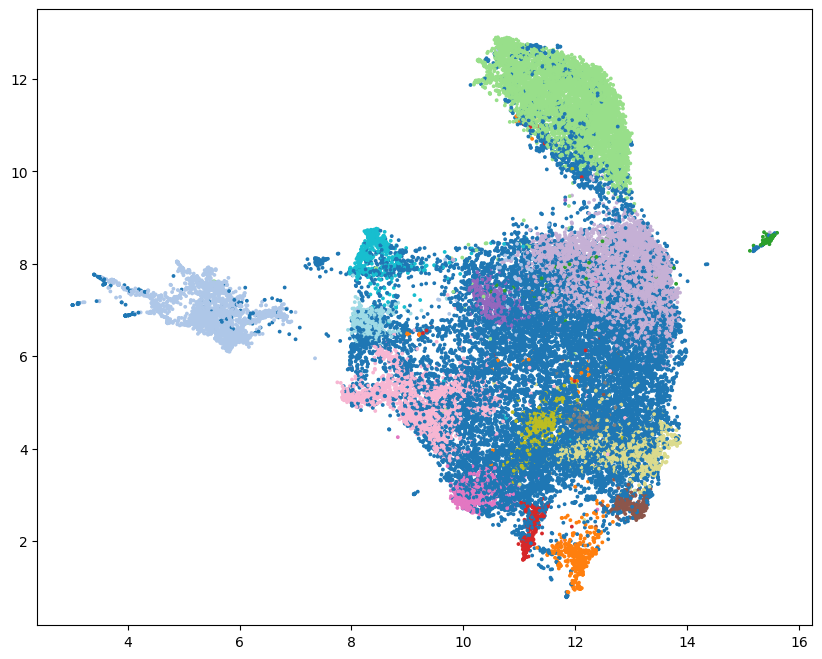

In [243]:
reducer2_for_viz = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.0,
    random_state=42
    )
umap2_2d = reducer2_for_viz.fit_transform(pca_pros_embeddings2)

mask2 = pros_labels2 != -1

plt.figure(figsize=(10, 8))
plt.scatter(
    umap2_2d[mask, 0],
    umap2_2d[mask, 1],
    c=pros_labels2[mask],
    cmap='tab20',
    s=3
)
plt.show()

In [244]:
df_IT_cleaned['cluster2'] = pros_labels2
print(df_IT_cleaned['cluster2'].value_counts())

cluster2
-1     16167
 3      6166
 6      4757
 0      2542
 9      2157
 12     1160
 13      689
 8       623
 1       567
 14      542
 11      500
 5       376
 2       351
 7       297
 4       290
 10      137
Name: count, dtype: int64


In [260]:
for j in df_IT_cleaned["cluster2"].value_counts().sort_values(ascending=False).index.tolist():
    if j == -1:
        continue
    else:
        print(analyze_cluster(df_IT_cleaned, "cluster2", j, pros_embeddings2, "pros_short", 3))

Work-Life Balance and Professional Growth
Excellent benefits and career opportunities
Good work-life balance and culture
Good Compensation, Benefits & Culture
Company provides diverse opportunities
Work from home flexibility
Positive Work Environment Leadership
Great place to work
Workplace flexibility and positive environment
Positive Work Experience
Excellent Workplace Environment and Benefits
Employee-Centric Growth & Benefits
Great for career start
Great colleagues to work with
Positive Company Environment and Growth


In [252]:
pros_df = df_IT_cleaned[df_IT_cleaned["cluster2"] != -1]

pros_cluster_docs = pros_df.groupby("cluster2")["pros_short"].apply(lambda x: " ".join(x))

pros_vectorizer = CountVectorizer(stop_words="english")
pros_X = pros_vectorizer.fit_transform(pros_cluster_docs)

pros_tf = pros_X.toarray() / pros_X.toarray().sum(axis=1, keepdims=True)

pros_df_idf = np.log(len(pros_cluster_docs) / (np.count_nonzero(pros_X.toarray(), axis=0)))
pros_c_tf_idf = pros_tf * pros_df_idf

pros_feature_names = pros_vectorizer.get_feature_names_out()
pros_cluster_sizes = pros_df.groupby("cluster2").size().sort_values(ascending=False)
pros_top_clusters = pros_cluster_sizes.index[:20]
pros_results = {}

for c in pros_top_clusters:
    pros_c_index = list(pros_cluster_docs.index).index(c)
    pros_top_indices = pros_c_tf_idf[pros_c_index].argsort()[-5:][::-1]
    pros_results[c] = pros_feature_names[pros_top_indices]

pros_results

{3: array(['balance', 'home', 'life', 'hours', 'timings'], dtype=object),
 6: array(['balance', 'll', 'want', 'don', 'home'], dtype=object),
 0: array(['balance', 'life', 'worklife', 'balanced', 'timings'], dtype=object),
 9: array(['pay', 'health', 'compensation', '401k', 'salary'], dtype=object),
 12: array(['learn', 'new', 'latest', 'edge', 'cutting'], dtype=object),
 13: array(['home', 'option', 'hours', 'flexibility', 'remote'], dtype=object),
 8: array(['friendly', 'culture', 'colleagues', 'supportive', 'staff'],
       dtype=object),
 1: array(['ok', 'women', 'aa', 'greate', 'helpfull'], dtype=object),
 14: array(['hours', 'timings', 'flexible', 'flexibility', 'timing'],
       dtype=object),
 11: array(['say', 'pros', 'think', 'mention', 'taste'], dtype=object),
 5: array(['balance', 'health', 'insurance', '401k', 'reimbursement'],
       dtype=object),
 2: array(['fosters', 'fostering', 'supported', 'complemented', 'significant'],
       dtype=object),
 7: array(['fresher', 'l

**Cons**

count    37321.000000
mean       156.069505
std        240.693420
min         12.000000
25%         44.000000
50%         79.000000
75%        173.000000
max       7413.000000
Name: clean_cons, dtype: float64


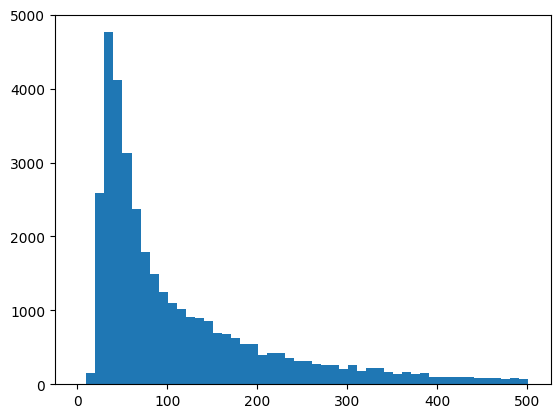

In [169]:
df_IT_cleaned['clean_cons'] = df_IT_cleaned['cons'].str.replace(pattern, '', regex=True, flags=re.IGNORECASE)

print(df_IT_cleaned["clean_cons"].str.len().describe())

plt.hist(df_IT_cleaned["clean_cons"].str.len(), bins=50, range=[0, 501])
plt.show()

In [170]:
def summarize_cons_with_progress(df, tokenizer, max_tokens=128):

    df = df.copy()
    df["token_length_cons"] = df["clean_cons"].apply(lambda x: count_tokens(x, tokenizer))

    long_idx = df.index[df["token_length_cons"] > max_tokens]

    print(f"Long texts to summarize: {len(long_idx)} 件")

    df["cons_short"] = df["clean_cons"]

    for idx in tqdm(long_idx, desc="Summarizing long cons"):
        original_text = df.at[idx, "clean_cons"]
        summarized = summarize_until_short(original_text, tokenizer, max_tokens=max_tokens)
        df.at[idx, "cons_short"] = summarized

    return df

In [171]:
# df_IT_cleaned = summarize_cons_with_progress(df_IT_cleaned, cb_tokenizer, max_tokens=128)

cons_list = df_IT_cleaned["clean_cons"].tolist()

In [172]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cb_model.to(device)

cons_embeddings = get_embeddings(cb_tokenizer, cb_model, cons_list, layer=12)
cons_embeddings = normalize(cons_embeddings)

100%|██████████| 2333/2333 [04:44<00:00,  8.21it/s]


In [177]:
pca3 = PCA(
    n_components=50
    )
pca_cons_embeddings = pca3.fit_transform(cons_embeddings)

In [248]:
reducer3 = umap.UMAP(
    n_neighbors=30,
    n_components=5,
    metric="cosine",
    random_state=42
)

umap_cons_embeddings = reducer3.fit_transform(pca_cons_embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [249]:
clusterer3 = hdbscan.HDBSCAN(
    min_cluster_size=100,
)
cons_labels = clusterer3.fit_predict(umap_cons_embeddings)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


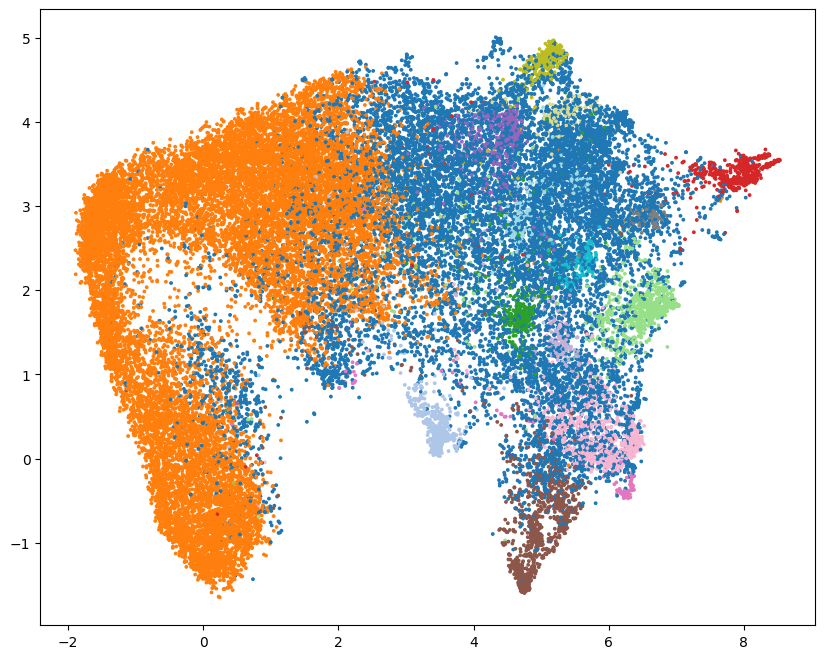

In [251]:
reducer3_for_viz = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,
    random_state=42
    )
umap3_2d = reducer2_for_viz.fit_transform(pca_cons_embeddings)

mask3 = cons_labels != -1

plt.figure(figsize=(10, 8))
plt.scatter(
    umap3_2d[mask, 0],
    umap3_2d[mask, 1],
    c=cons_labels[mask],
    cmap='tab20',
    s=3
)
plt.show()

In [250]:
df_IT_cleaned['cons_cluster'] = cons_labels
print(df_IT_cleaned['cons_cluster'].value_counts())

cons_cluster
 1     17808
-1     13170
 7      1091
 3       853
 9       847
 4       650
 0       517
 5       513
 2       424
 11      393
 14      304
 13      223
 6       153
 12      130
 8       128
 10      117
Name: count, dtype: int64


In [261]:
for j in df_IT_cleaned["cons_cluster"].value_counts().sort_values(ascending=False).index.tolist():
    if j == -1:
        continue
    else:
        print(analyze_cluster(df_IT_cleaned, "cons_cluster", j, cons_embeddings, "clean_cons", 3))

Bad Management Practices and Employee Impact
Low market-rate salary
Limited Career Growth Opportunities
Lack of employee compensation/rewards
No identified disadvantages
Poor Management and Work-Life Balance
Unethical management practices
Long, Demanding Work Hours
Poor Management and Internal Issues
Bureaucracy and Poor Leadership
Poor management and lack of vision
Workplace Environment and Employee Issues
Challenges of change in large organizations
No salary hike for years
Poor work culture


In [255]:
cons_df = df_IT_cleaned[df_IT_cleaned["cons_cluster"] != -1]

cons_cluster_docs = cons_df.groupby("cons_cluster")["clean_cons"].apply(lambda x: " ".join(x))

cons_vectorizer = CountVectorizer(stop_words="english")
cons_X = cons_vectorizer.fit_transform(cons_cluster_docs)

cons_tf = cons_X.toarray() / cons_X.toarray().sum(axis=1, keepdims=True)

cons_df_idf = np.log(len(cons_cluster_docs) / (np.count_nonzero(cons_X.toarray(), axis=0)))
cons_c_tf_idf = cons_tf * cons_df_idf

cons_feature_names = cons_vectorizer.get_feature_names_out()
cons_cluster_sizes = cons_df.groupby("cons_cluster").size().sort_values(ascending=False)
cons_top_clusters = cons_cluster_sizes.index[:20]
cons_results = {}

for c in cons_top_clusters:
    cons_c_index = list(cons_cluster_docs.index).index(c)
    cons_top_indices = cons_c_tf_idf[cons_c_index].argsort()[-5:][::-1]
    cons_results[c] = cons_feature_names[cons_top_indices]

cons_results

{1: array(['like', 'day', 'customers', 'll', 'balance'], dtype=object),
 7: array(['salary', 'compared', 'standards', 'compare', 'market'],
       dtype=object),
 3: array(['career', 'opportunity', 'opportunities', 'advancement', 'limited'],
       dtype=object),
 9: array(['hike', 'salary', 'bonus', 'hikes', 'bonuses'], dtype=object),
 4: array(['think', 'cons', 'mention', 'say', 'moment'], dtype=object),
 0: array(['balance', 'life', 'worklife', 'stressful', 'maintain'],
       dtype=object),
 5: array(['bit', 'chain', 'stressful', 'goes', 'matter'], dtype=object),
 2: array(['hours', 'week', 'long', 'stressful', 'days'], dtype=object),
 11: array(['tape', 'layers', 'red', 'bureaucracy', 'big'], dtype=object),
 14: array(['hierarchical', 'bureaucracy', 'bureaucratic', 'bureacratic',
        'siloed'], dtype=object),
 13: array(['lack', 'upper', 'vision', 'communication', 'direction'],
       dtype=object),
 6: array(['salary', 'benefits', 'career', 'heirachial', 'carriere'],
       d